# MMIP: HW2

<hr style="border:none; border-top:2px solid #4C72B0; margin-top:2em;">


## Quiz 1: 機器學習分類任務
- 資料集：Pima Indians Diabetes（768 筆，8 個特徵，二元分類：是否患有糖尿病）
- 模型：Logistic Regression（基礎）、Random Forest（進階）
- 輸出位置：`result/quiz1/`

### 基礎：Logistic Regression

混淆矩陣圖片已儲存至: result/quiz1/confusion_matrices.png


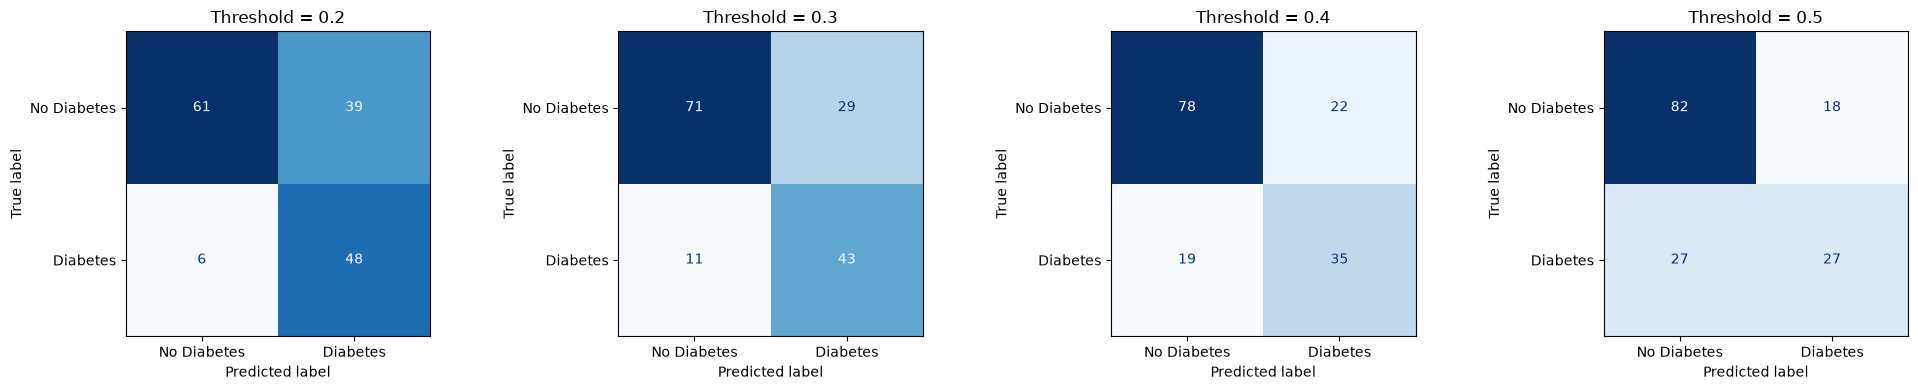

表格圖片已儲存至: result/quiz1/comparison_table.png


,threshold,accuracy,precision,recall,f1
threshold_0.2,0.2,0.708,0.552,0.889,0.681
threshold_0.3,0.3,0.740,0.597,0.796,0.683
threshold_0.4,0.4,0.734,0.614,0.648,0.631
threshold_0.5,0.5,0.708,0.600,0.500,0.545


In [1]:
import sys
sys.path.append('src/quiz1')
import os
from preprocessing import load_and_clean_data, split_and_scale
from train import train_model, get_probabilities
from evaluate import evaluate_at_threshold, compare_models
from evaluate import save_table_as_image
from confusionMatrices import plot_confusion_matrices

# 確保輸出目錄存在
output_dir = "result/quiz1"
os.makedirs(output_dir, exist_ok=True)

# 讀資料、前處理
df = load_and_clean_data('dataset/pima-indians-diabetes.data.csv')
X_train, X_val, y_train, y_val = split_and_scale(df) # 把資料切成訓練集與驗證集，並做標準化

# 模型一:Logistic Regression
from sklearn.linear_model import LogisticRegression
model1 = train_model(LogisticRegression(), X_train, y_train)
proba1 = get_probabilities(model1, X_val)

# 用不同threshold評估模型一的表現
thresholds = [0.2, 0.3, 0.4, 0.5]  # 想測哪些值，改這個 list

cms = []
results = {}

for t in thresholds:
    cm, metrics = evaluate_at_threshold(y_val, proba1, t)
    cms.append(cm)
    results[f'threshold_{t}'] = metrics
# 畫出混淆矩陣
plot_confusion_matrices(
    cms, thresholds, save_path=f"{output_dir}/confusion_matrices.png"
)
# 產生比較表格並存成圖片
comparison_table = compare_models(results).round(3)

# 儲存為類似 Word 的表格圖
save_table_as_image(
    comparison_table, save_path="result/quiz1/comparison_table.png"
)

# Notebook 內依然可以直接預覽
comparison_table

### 進階：Random Forest

混淆矩陣圖片已儲存至: result/quiz1/confusion_matrices_RandomForest.png


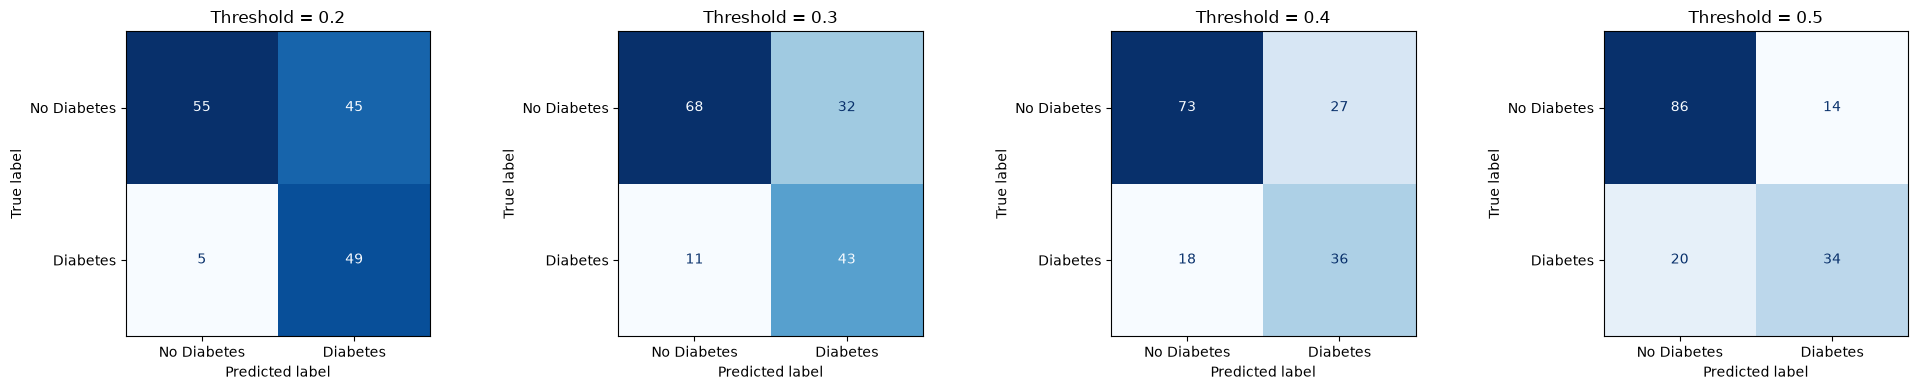

表格圖片已儲存至: result/quiz1/comparison_table_RandomForest.png


,threshold,accuracy,precision,recall,f1
RF_threshold_0.2,0.2,0.675,0.521,0.907,0.662
RF_threshold_0.3,0.3,0.721,0.573,0.796,0.667
RF_threshold_0.4,0.4,0.708,0.571,0.667,0.615
RF_threshold_0.5,0.5,0.779,0.708,0.630,0.667


In [2]:
from sklearn.ensemble import RandomForestClassifier

model2 = train_model(RandomForestClassifier(random_state=42), X_train, y_train) # 模型二:Random Forest
proba2 = get_probabilities(model2, X_val)

thresholds = [0.2, 0.3, 0.4, 0.5]

cms2 = []
results2 = {}

for t in thresholds:
    cm, metrics = evaluate_at_threshold(y_val, proba2, t)
    cms2.append(cm)
    results2[f'RF_threshold_{t}'] = metrics

plot_confusion_matrices(
    cms2, thresholds, save_path=f"{output_dir}/confusion_matrices_RandomForest.png"
)

# 存到新變數 comparison_table2,不要沿用 comparison_table
comparison_table2 = compare_models(results2).round(3)

save_table_as_image(
    comparison_table2, save_path="result/quiz1/comparison_table_RandomForest.png"
)

comparison_table2   # 這裡也要改成 comparison_table2,才會印出 RF 的正確結果

### Logistic Regression與Random Forest的比較
輸出Logistic Regression與Random Forest最佳threshold的混淆矩陣及Accuracy、Precision、Recall、F1-Score並進行比較

找出合適的threshold：  
雖然此情形為醫療情況，漏抓越低越好，但兩個模型在 threshold = 0.2 中，誤抓數量都大幅增加，兩個模型在 threshold = 0.3 的 f1-score 指標都較高，因此我都選擇 0.3 為最佳threshold  
  
模型比較：  
兩者在 Recall 上是一樣的，Precision 則是 Logistic Regression 略高，但因資料量不多，比較的差異較不明顯

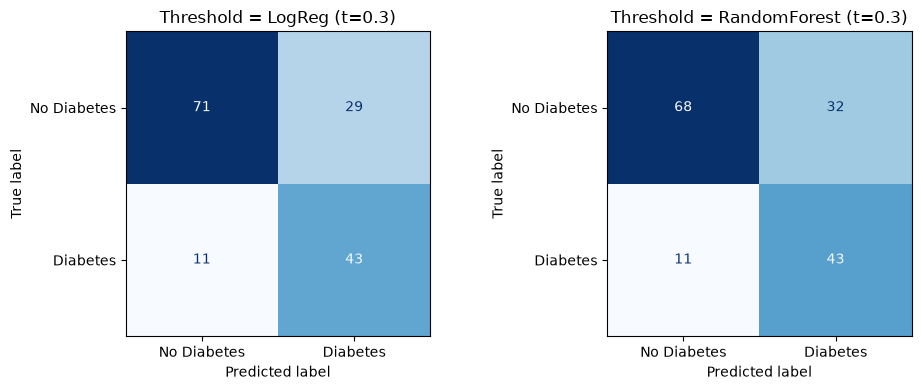

,threshold,accuracy,precision,recall,f1
LogReg_t0.3,0.3,0.740,0.597,0.796,0.683
RandomForest_t0.3,0.3,0.721,0.573,0.796,0.667


In [3]:
best_t_lr = 0.3
best_t_rf = 0.3

cm_lr_final, metrics_lr_final = evaluate_at_threshold(y_val, proba1, best_t_lr)
cm_rf_final, metrics_rf_final = evaluate_at_threshold(y_val, proba2, best_t_rf)

# 兩個模型的混淆矩陣並排畫出來
plot_confusion_matrices(
    [cm_lr_final, cm_rf_final],
    [f'LogReg (t={best_t_lr})', f'RandomForest (t={best_t_rf})'],
)

# 指標表格也用這兩個 metrics 重新組一次,確保跟混淆矩陣對應的是同一組 threshold
final_results = {
    f'LogReg_t{best_t_lr}': metrics_lr_final,
    f'RandomForest_t{best_t_rf}': metrics_rf_final,
}
final_comparison = compare_models(final_results).round(3)

final_comparison

<hr style="border:none; border-top:2px solid #4C72B0; margin-top:2em;">


## Quiz 2: 深度學習信用卡違約預測
- 資料集：UCI Credit Card（30000 筆，違約比例約 22%）
- 框架：PyTorch
- 程式模組：`src/quiz2/`（preprocessing / model / train / evaluate）
- 輸出位置：`result/quiz2/`

### 基礎

In [4]:
import torch
from src.quiz2.preprocessing import ROOT, load_data, make_loaders
from src.quiz2.model import MLP
from src.quiz2.train import train_model
from src.quiz2.evaluate import (predict_proba, compute_metrics, predict_one_sample,
                                plot_loss, plot_confusion_matrix)

RESULT_DIR = ROOT / "result" / "quiz2"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Device:", device)

In [5]:
# ===== 超參數 =====
EPOCHS = 100             # 訓練幾輪
BATCH_SIZE = 128         # 每次更新權重使用幾筆資料
LR = 1e-3               # 學習率（每次更新的步伐大小）
OPTIMIZER = "adam"      # 可選 "adam"、"adamw"、"sgd"
HIDDEN = (64, 32)       # 2 層隱藏層，各層的神經元數量
TH = 0.3                 # threshold

1. 載入資料

In [6]:
torch.manual_seed(42)
X_train, X_val, y_train, y_val, feature_names = load_data()
train_loader, val_loader = make_loaders(X_train, X_val, y_train, y_val, batch_size=BATCH_SIZE)

print("Train:", X_train.shape, " Val:", X_val.shape)

Train: (24000, 30)  Val: (6000, 30)


2. 建立模型並訓練

In [7]:
model = MLP(in_dim=X_train.shape[1], hidden=HIDDEN)
print(model)

history = train_model(model, train_loader, val_loader,
                      epochs=EPOCHS, lr=LR, optimizer_name=OPTIMIZER, device=device)

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch   1 | train 0.4712 | val 0.4473
Epoch   2 | train 0.4380 | val 0.4411
Epoch   3 | train 0.4335 | val 0.4390
Epoch   4 | train 0.4306 | val 0.4372
Epoch   5 | train 0.4280 | val 0.4366
Epoch   6 | train 0.4262 | val 0.4368
Epoch   7 | train 0.4248 | val 0.4370
Epoch   8 | train 0.4238 | val 0.4381
Epoch   9 | train 0.4224 | val 0.4380
Epoch  10 | train 0.4216 | val 0.4371
Epoch  11 | train 0.4204 | val 0.4367
Epoch  12 | train 0.4196 | val 0.4393
Epoch  13 | train 0.4184 | val 0.4375
Epoch  14 | train 0.4175 | val 0.4374
Epoch  15 | train 0.4163 | val 0.4376
Epoch  16 | train 0.4149 | val 0.4405
Epoch  17 | train 0.4142 | val 0.4389
Epoch  18 | train 0.4133 | val 0.4371
Epoch  19 | train 0.4122 | val 0.4394
Epoch  20 | train 0.4122 | val 0.43

3. 畫出loss圖及混淆矩陣並計算指標

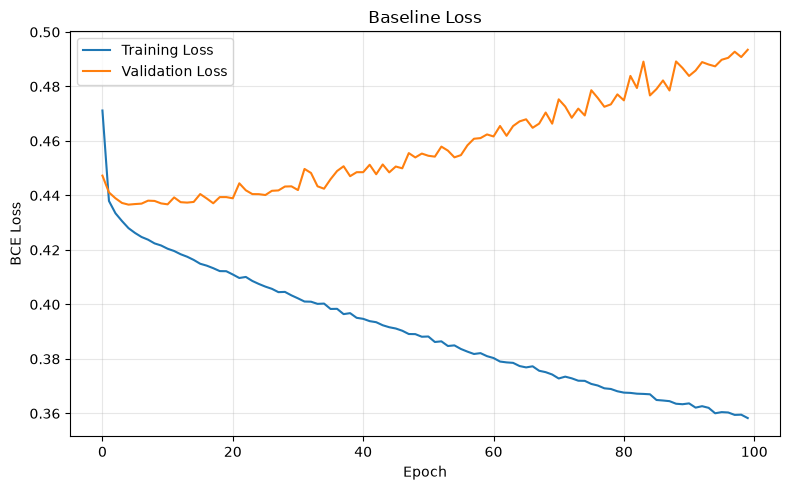

accuracy     0.7753
precision    0.4922
recall       0.4989
f1           0.4955
Name: Baseline, dtype: float64


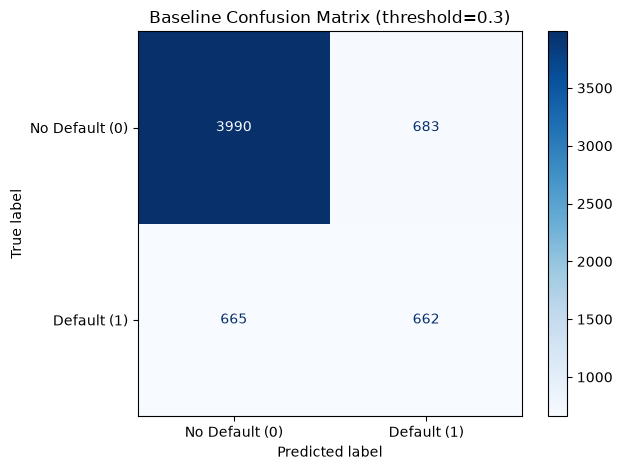

In [8]:
import pandas as pd

plot_loss(history, "Baseline Loss", RESULT_DIR / "baseline_loss.png")

prob = predict_proba(model, X_val, device)

# 四個指標
metrics = compute_metrics(y_val, prob, threshold=TH)
metrics_df = pd.Series(metrics, name="Baseline").round(4)
# metrics_df.to_csv(RESULT_DIR / "baseline_metrics.csv")
print(metrics_df)

# 混淆矩陣
cm = plot_confusion_matrix(y_val, prob, f"Baseline Confusion Matrix (threshold={TH})",
                           RESULT_DIR / "baseline_confusion_matrix.png", threshold=TH)
# 保存基本模型結果留著待會比較
base_model = model
base_history = history
base_prob = prob
base_metrics = metrics
# print("Baseline:", base_metrics)
# tn, fp, fn, tp = cm.ravel()
# print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

4. 展示一筆 Validation Sample 的預測

In [9]:
sample = predict_one_sample(model, X_val, y_val, idx=0, device=device)
print(sample)

{'index': 0, 'prob_default': 0.031, 'predicted': 0, 'actual': 0}


In [10]:
from src.quiz2.evaluate import plot_compare, plot_metrics_bar

# 把 Baseline 的結果另外存一份，避免之後被覆蓋
base_model = model
base_history = history
base_prob = predict_proba(base_model, X_val, device)
base_metrics = compute_metrics(y_val, base_prob, threshold=TH)
print("Baseline:", base_metrics)

Baseline: {'accuracy': 0.7753333333333333, 'precision': 0.4921933085501859, 'recall': 0.49886963074604374, 'f1': 0.49550898203592814}


### 進階

- 模型改善（Dropout + L2 Regularization + Early Stopping）

In [11]:
# ===== 模型改善 =====
DROPOUT = 0.3          # 改善 1：Dropout 訓練時，每一個 batch 都會隨機關掉 30% 的神經元
WEIGHT_DECAY = 1e-4    # 改善 2：L2 Regularization
PATIENCE = 20          # 改善 3：Early Stopping

1. 訓練 Improved 模型

In [12]:
torch.manual_seed(42)
train_loader, val_loader = make_loaders(X_train, X_val, y_train, y_val, batch_size=BATCH_SIZE)

imp_model = MLP(in_dim=X_train.shape[1], hidden=HIDDEN, dropout=DROPOUT)
print(imp_model)

imp_history = train_model(imp_model, train_loader, val_loader,
                          epochs=EPOCHS, lr=LR, optimizer_name=OPTIMIZER,
                          weight_decay=WEIGHT_DECAY,
                          early_stopping_patience=PATIENCE,
                          device=device)

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch   1 | train 0.4835 | val 0.4503
Epoch   2 | train 0.4508 | val 0.4466
Epoch   3 | train 0.4451 | val 0.4414
Epoch   4 | train 0.4412 | val 0.4392
Epoch   5 | train 0.4393 | val 0.4387
Epoch   6 | train 0.4379 | val 0.4369
Epoch   7 | train 0.4371 | val 0.4361
Epoch   8 | train 0.4361 | val 0.4358
Epoch   9 | train 0.4335 | val 0.4361
Epoch  10 | train 0.4338 | val 0.4364
Epoch  11 | train 0.4346 | val 0.4352
Epoch  12 | train 0.4325 | val 0.4356
Epoch  13 | train 0.4313 | val 0.4347
Epoch  14 | train 0.4316 | val 0.4344
Epoch  15 | train 0.4304 | val 0.4348
Epoch  16 | train 0.4302 | val 0.4342
Epoch  17 | train 0.4299 | val 0.4338
Epoch  18 | train 0.4290 | val 0.

2. 畫出 Improved 的 loss 圖、指標和混淆矩陣

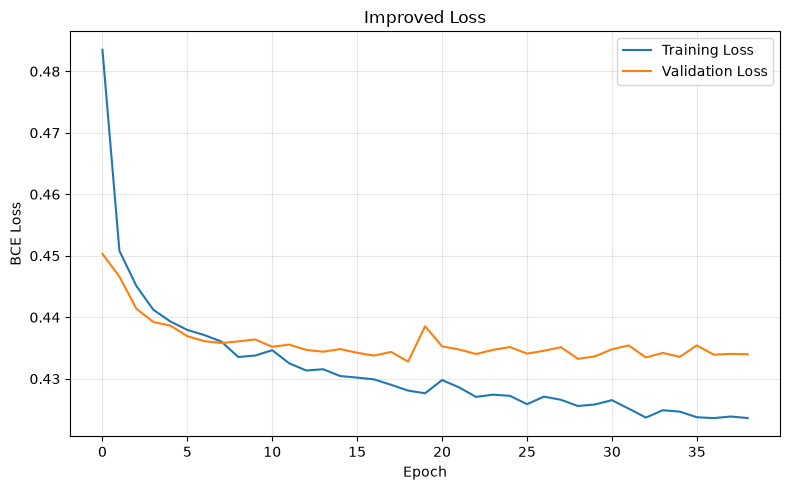

Improved: {'accuracy': 0.7921666666666667, 'precision': 0.5290275761973875, 'recall': 0.549359457422758, 'f1': 0.5390018484288355}


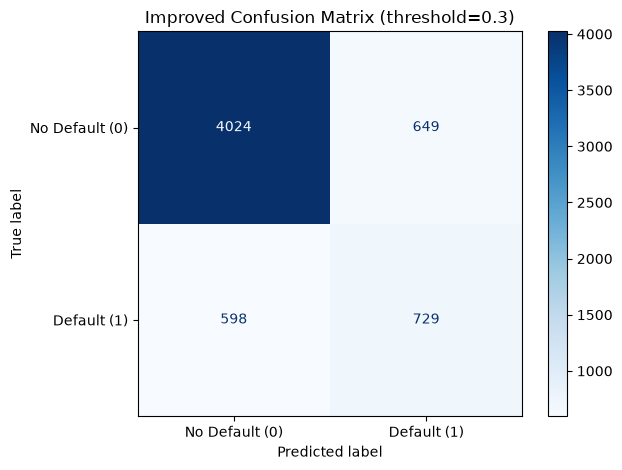

TN=4024  FP=649  FN=598  TP=729


In [13]:
plot_loss(imp_history, "Improved Loss", RESULT_DIR / "improved_loss.png")

imp_prob = predict_proba(imp_model, X_val, device)
imp_metrics = compute_metrics(y_val, imp_prob, threshold=TH)
print("Improved:", imp_metrics)

cm_imp = plot_confusion_matrix(y_val, imp_prob, f"Improved Confusion Matrix (threshold={TH})",
                               RESULT_DIR / "improved_confusion_matrix.png", threshold=TH)
tn, fp, fn, tp = cm_imp.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

3. 比較 Baseline 與 Improved 的 training loss 與 validation loss

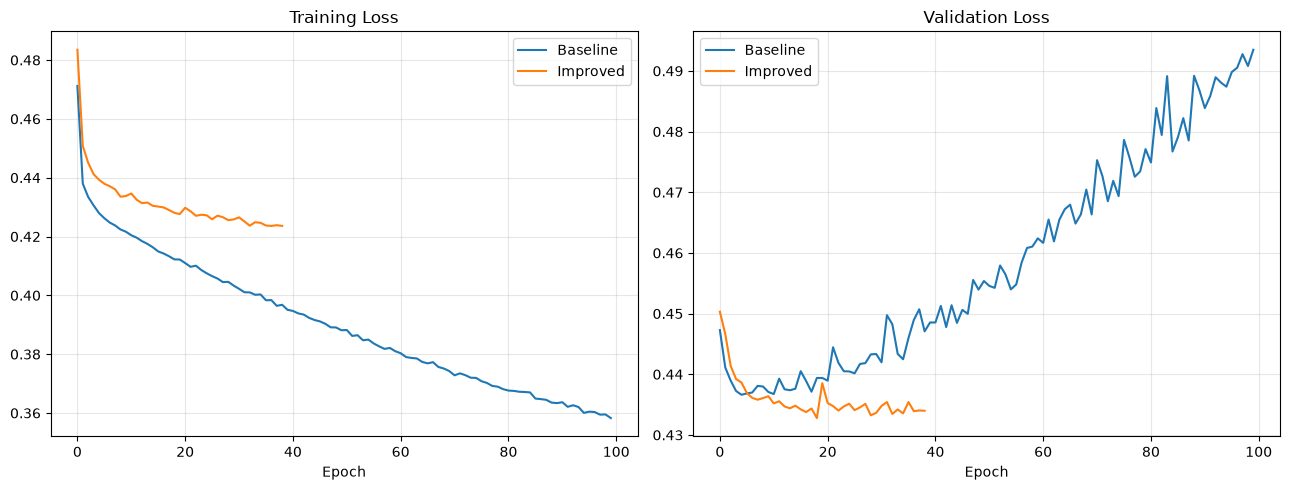

In [14]:
plot_compare(base_history, imp_history, RESULT_DIR / "compare_loss.png")

4. 比較 Baseline 與 Improved 的 Accuracy / Precision / Recall / F1-Score

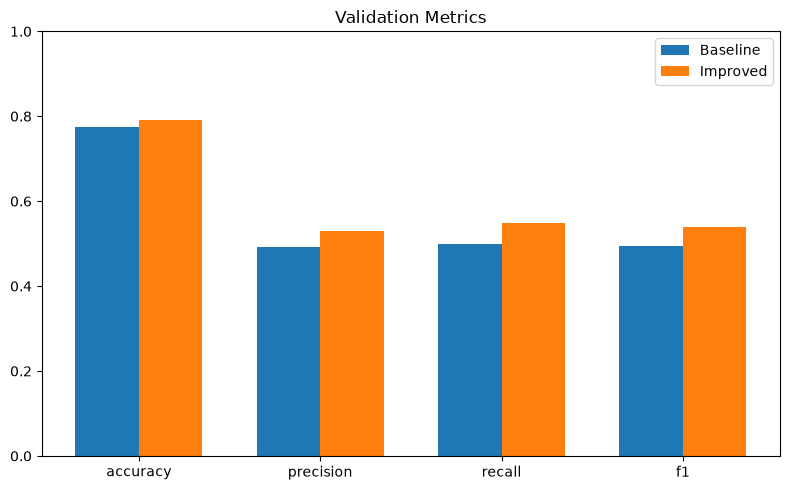

,Baseline,Improved
accuracy,0.7753,0.7922
precision,0.4922,0.5290
recall,0.4989,0.5494
f1,0.4955,0.5390
best_val_loss,0.4366,0.4328
final_val_loss,0.4935,0.4340
epochs_trained,100.0000,39.0000


In [15]:
plot_metrics_bar(base_metrics, imp_metrics, RESULT_DIR / "compare_metrics.png")

compare = pd.DataFrame({"Baseline": base_metrics, "Improved": imp_metrics})
compare.loc["best_val_loss"] = [base_history["best_val_loss"], imp_history["best_val_loss"]]
compare.loc["final_val_loss"] = [base_history["val_loss"][-1], imp_history["val_loss"][-1]]
compare.loc["epochs_trained"] = [base_history["stopped_epoch"], imp_history["stopped_epoch"]]
# compare.to_csv(RESULT_DIR / "compare_metrics.csv")
compare.round(4)

5. 分析原始模型與改善後的差別

- 因為使用了 Dropout 和 L2 Regularization，所以 training loss 下降的較慢，再加上 Early stopping 讓 training 提早結束
- Baseline 的 val loss 在 Epoch = 20 後持續上升，有過擬合的趨勢，Improved 的 val loss 則穩定維持在 0.433~0.436，最佳的 val loss 也有下降 0.0038
- 同一個模型的 training loss 和 validation loss 之間，Baseline 的差距隨著訓練持續擴大，Improved 的差距則幾乎差不多，Overfitting 獲得改善
- Baseline 後期的 Validation Loss 波動明顯，Improved 的 Validation Loss 波動範圍小，模型表現更穩定
- 由於資料中違約樣本僅約 22%，threshold = 0.5 時 Recall 偏低，因此兩個模型皆使用 threshold = 0.3 進行比較，Baseline 與 Improved 模型四個指標在 threshold = 0.3 的比較中，Improved 的指標都略高於 Baseline

<hr style="border:none; border-top:2px solid #4C72B0; margin-top:2em;">


## Quiz 3: 模型表現評估

In [16]:
from sklearn.ensemble import RandomForestClassifier
from src.quiz3.evaluate import plot_roc_curves

Q3_DIR = ROOT / "result" / "quiz3"
Q3_DIR.mkdir(parents=True, exist_ok=True)

1. MLP 的機率、ROC Curve 與 AUC

MLP 前 5 筆預測機率： [0.1166 0.1258 0.1631 0.0624 0.045 ]


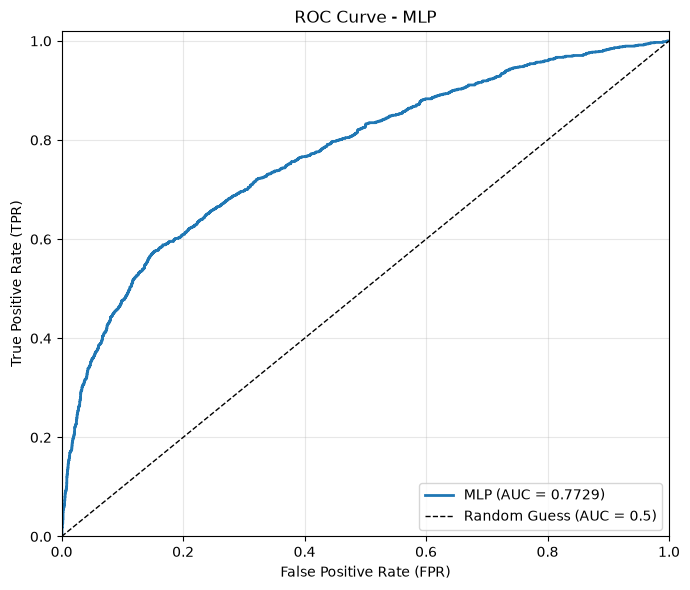

{'MLP': 0.7728661710211026}


In [17]:
mlp_prob = predict_proba(imp_model, X_val, device) # 取得了全部 6000 筆
print("MLP 前 5 筆預測機率：", mlp_prob[:5].round(4)) # 只印出前五筆

mlp_auc = plot_roc_curves(y_val, {"MLP": mlp_prob},
                          "ROC Curve - MLP", Q3_DIR / "roc_mlp.png")
print(mlp_auc) 

- ROC Curve 是 threshold 從1逐漸降到0中，紀錄每個 threshold 下的FPR和TPR所畫出的曲線，對角虛線則代表隨機猜測
- MLP 的 AUC 為 0.7729，代表隨機挑選一個違約者與未違約者時，模型約有77%的機率會給違約者較高的違約機率，明顯優於隨機猜測

2. 訓練 Random Forest 並取得機率

In [18]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=8,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_val)[:, 1]
print("RF 前 5 筆預測機率：", rf_prob[:5].round(4))

RF 前 5 筆預測機率： [0.1341 0.1548 0.1466 0.1457 0.065 ]


3. 比較兩種模型

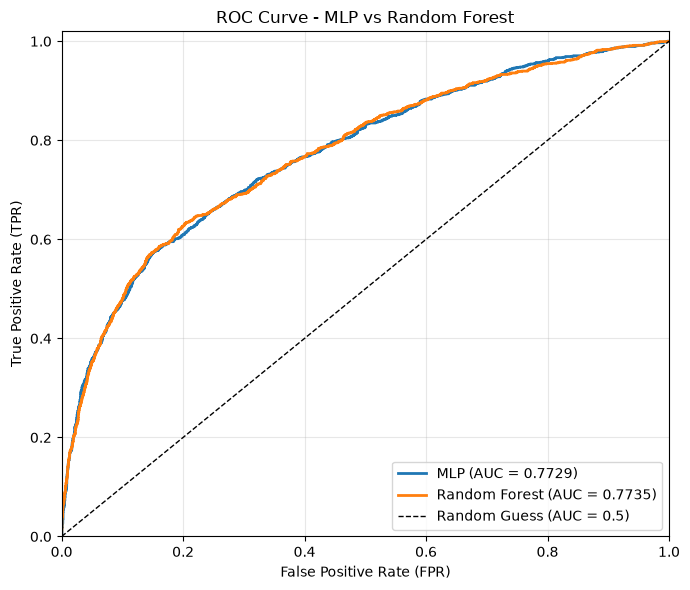

MLP: AUC = 0.7729
Random Forest: AUC = 0.7735


In [19]:
aucs = plot_roc_curves(y_val, {"MLP": mlp_prob, "Random Forest": rf_prob},
                       "ROC Curve - MLP vs Random Forest", Q3_DIR / "roc_compare.png")

for name, auc in aucs.items():
    print(f"{name}: AUC = {auc:.4f}")

### 比較兩者模型的ROC Curve和AUC

MLP 的 AUC 為 0.7729，Random Forest 為 0.7735，兩者僅相差 0.0006，ROC 曲線幾乎完全重疊，且都優於 Random guess，雖然 Random Forest 的 AUC 略高，但差距極小，因此判斷兩個模型在判斷信用卡違約預測中能力相當